In [1]:
## load packages
import nltk
nltk.download('stopwords')

import pandas as pd
import re
import numpy as np
# import plotnine
# from plotnine import *
import pickle

## nltk imports
from nltk.tokenize import word_tokenize, wordpunct_tokenize
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

## sklearn imports
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

## print mult things
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## random
import random

pd.set_option('display.max_colwidth', None)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/victoriatan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# Function that Processes Text
def processtext(one_str, stop_list):

    ## remove stopwords
    no_stop = [tok for tok in wordpunct_tokenize(one_str)
              if tok not in stop_list]


    processed_string = " ".join([porter.stem(i.lower())
                        for i in no_stop if
                        i.lower().isalpha() and len(i) >=3])
    return(processed_string)

In [3]:
# Assigning text for commercial and personal binary in vectorization process
def label_post(text):
    text_lower = text.lower()

    commercial_signals = [
        r'link in bio', r'swipe up', r'use code', r'promo code',
        r'discount', r'affiliate', r'sponsored', r'#ad\b', r'#spon\b',
        r'shop now', r'buy now', r'dm me', r'click the link',
        r'\$\d+', r'% off', r'free shipping', r'collab'
    ]

    for pattern in commercial_signals:
        if re.search(pattern, text_lower):
            return 1

    return 0

In [4]:
# Function that creates a word count table/document term matrix
def create_dtm(list_of_strings, metadata):
  # Adding max_features caps the columns so your RAM doesn't crash
  vectorizer = TfidfVectorizer(
      ngram_range=(1, 2),
      sublinear_tf=True,
      min_df=5,             # Ignore terms that appear in fewer than 5 documents
      max_features=10000    # Keeps the column count manageable
  )
  dtm_sparse = vectorizer.fit_transform(list_of_strings)
  
  # Using toarray() is more memory stable than todense()
  dtm_dense_named = pd.DataFrame(
      dtm_sparse.toarray(),
      columns=vectorizer.get_feature_names_out()
  )
  
  # Use drop=True to avoid creating a duplicate 'index' column
  dtm_dense_named_withid = pd.concat(
      [metadata.reset_index(drop=True), dtm_dense_named], 
      axis=1
  )
  return dtm_dense_named_withid

In [5]:
tcm_df = pd.read_csv("../Data/cleanedData.csv")

In [6]:
# selecting only creator accounts
tcm_df_creator = tcm_df[tcm_df["post_owner.type"] == "creator"]

In [7]:
import gc

porter = PorterStemmer()
list_stopwords = stopwords.words("english")

# Fill NaN values in 'text_clean' with empty strings before applying label_post
tcm_df_creator['label'] = tcm_df_creator['text_clean'].fillna('').apply(label_post)
tcm_df_creator['process_text'] = [processtext(caption, stop_list=list_stopwords) for caption in tcm_df_creator['text_clean'].fillna('')]

# This is where tcm_creator_dtm gets created
tcm_creator_dtm = create_dtm(
    tcm_df_creator['process_text'],
    tcm_df_creator[['label', 'id', 'process_text', 'text_clean']]
)

# --- NEW SNIPPETS TO SAVE RAM ---
# Delete the massive uncleaned DataFrames you no longer need
if 'tcm_df' in locals(): del tcm_df
if 'tcm_df_creator' in locals(): del tcm_df_creator

# Force Python to clear your Google Colab RAM instantly
gc.collect()

/var/folders/b6/wrdkj8hj3ql3z0pmfbh_yrw80000gn/T/ipykernel_1748/2107423178.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tcm_df_creator['label'] = tcm_df_creator['text_clean'].fillna('').apply(label_post)
/var/folders/b6/wrdkj8hj3ql3z0pmfbh_yrw80000gn/T/ipykernel_1748/2107423178.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tcm_df_creator['process_text'] = [processtext(caption, stop_list=list_stopwords) for caption in tcm_df_creator['text_clean'].fillna('')]


0

NameError: name 'tcm_df_creator' is not defined

In [9]:
tcm_creator_dtm_clean = tcm_creator_dtm.dropna(subset=['label']).copy()

# Reset index so rows align perfectly
tcm_creator_dtm_clean = tcm_creator_dtm_clean.reset_index(drop=True)

# FIX: Explicitly grab only the FIRST 'label' column as a 1D Series
y = tcm_creator_dtm_clean['label'].iloc[:, 0] if isinstance(tcm_creator_dtm_clean['label'], pd.DataFrame) else tcm_creator_dtm_clean['label']

# FIX: Drop both columns if duplicate labels exist, along with ID and text columns
X = tcm_creator_dtm_clean.drop(columns=['label', 'index', 'id', 'text_clean', 'process_text'], errors='ignore')

# New Sanity Check (The second number for y.shape should now be blank/empty)
print("X shape:", X.shape, "y shape:", y.shape)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model setup using the memory-efficient SAGA solver
logit_lasso = LogisticRegression(
    penalty="l1", 
    C=1.0, 
    solver="saga", 
    max_iter=100,
    random_state=42
)

# Fit the model safely
logit_lasso.fit(X_train, y_train)

X shape: (7588, 9998) y shape: (7588,)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,penalty,'l1'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'saga'
,max_iter,100
,multi_class,'deprecated'


In [10]:
y_pred = logit_lasso.predict(X_test)

y_predprob = logit_lasso.predict_proba(X_test)

In [11]:
y_pred[0:5]
y_predprob[0:5]

array([0, 0, 0, 0, 0])

array([[0.97241531, 0.02758469],
       [0.64599871, 0.35400129],
       [0.91007989, 0.08992011],
       [0.96235103, 0.03764897],
       [0.95967657, 0.04032343]])

In [12]:
y_pred_df = pd.DataFrame({'y_pred_binary': y_pred,
                         'y_pred_continuous': [one_prob[1]
                                            for one_prob in y_predprob],
                         'y_true': y_test})
y_pred_df.sample(n = 10, random_state = 4484)

,y_pred_binary,y_pred_continuous,y_true
3396,0,0.027585,0
2303,0,0.102894,0
4864,0,0.031517,0
2229,0,0.027585,0
6098,0,0.048620,0
554,0,0.034998,0
132,0,0.045156,0
401,0,0.031517,0
2650,0,0.085073,1
2417,0,0.038084,0


In [13]:
error_cond = [(y_pred_df['y_true'] == 1) & (y_pred_df['y_pred_binary'] == 1),
             (y_pred_df['y_true'] == 1) & (y_pred_df['y_pred_binary'] == 0),
              (y_pred_df['y_true'] == 0) & (y_pred_df['y_pred_binary'] == 0)]

error_codeto = ["TP", "FN", "TN"]

y_pred_df['error_cat'] = np.select(error_cond, error_codeto, default = "FP")
y_error = y_pred_df.error_cat.value_counts().reset_index().copy()
y_error.columns = ['cat', 'n']
print(y_error)

# Safely get counts for TP, FP, FN, TN
def get_count(df, category):
    if category in df['cat'].values:
        return df.loc[df['cat'] == category, 'n'].iloc[0]
    return 0

tp = get_count(y_error, "TP")
fp = get_count(y_error, "FP")
fn = get_count(y_error, "FN")
tn = get_count(y_error, "TN")

print(f"\nCounts: TP={tp}, FP={fp}, FN={fn}, TN={tn}")

### precision
print("\nPrecision is:-----------")
if (tp + fp) > 0:
    precision = tp / (tp + fp)
    print(precision)
else:
    print("Cannot calculate precision: TP + FP = 0")

### recall
print("\nRecall is:---------------")
if (tp + fn) > 0:
    recall = tp / (tp + fn)
    print(recall)
else:
    print("Cannot calculate recall: TP + FN = 0")

  cat     n
0  TN  1333
1  TP    95
2  FN    78
3  FP    12

Counts: TP=95, FP=12, FN=78, TN=1333

Precision is:-----------
0.8878504672897196

Recall is:---------------
0.5491329479768786


In [14]:
# Define non_feat to exclude non-feature columns
non_feat = ['label', 'id', 'text_clean', 'process_text']

las_coef = pd.DataFrame({'coef': logit_lasso.coef_[0],
                         'feature_name':
                        [col for col in X_train.columns if col not in non_feat]})
las_coef.sort_values(by = 'coef', ascending = False)


top_feat = las_coef.sort_values(by = 'coef', ascending = False)[0:10]
top_feat_list = top_feat.feature_name.to_list()

# Correcting yelp_dtm to tcm_creator_dtm and metadata_label to label
# Explicitly ensuring the 'label' grouper is a 1-dimensional Series
all_agg = [tcm_creator_dtm.groupby(tcm_creator_dtm['label'].iloc[:, 0]).agg({one_feat: np.mean})
for one_feat in top_feat_list]
all_agg_df = pd.concat(all_agg, axis = 1)
all_agg_df

,coef,feature_name
1652,34.554068,collabor
4989,30.377910,link bio
2333,16.460029,discount
5257,13.338260,manta
9295,11.705715,use code
...,...,...
3923,-0.963455,healthi
1363,-1.918799,channel
9509,-3.933943,watch
8736,-4.013939,the link


/var/folders/b6/wrdkj8hj3ql3z0pmfbh_yrw80000gn/T/ipykernel_1748/1501329758.py:15: FutureWarning: The provided callable <function mean at 0x104b4a340> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  all_agg = [tcm_creator_dtm.groupby(tcm_creator_dtm['label'].iloc[:, 0]).agg({one_feat: np.mean})


,collabor,link bio,discount,manta,use code,click link,link,singapor,onli,collab
label,,,,,,,,,,
0,0.000000,0.001671,0.000000,0.000000,0.000029,0.000146,0.006062,0.000530,0.000719,0.000000
1,0.008745,0.041881,0.006699,0.002165,0.006964,0.006991,0.041319,0.005094,0.004148,0.002578


<Figure size 1000x600 with 0 Axes>

<BarContainer object of 5 artists>

<BarContainer object of 5 artists>

Text(0.5, 0, 'Coefficient Value')

Text(0.5, 1.0, 'Top 5 Positive and Negative Feature Coefficients')

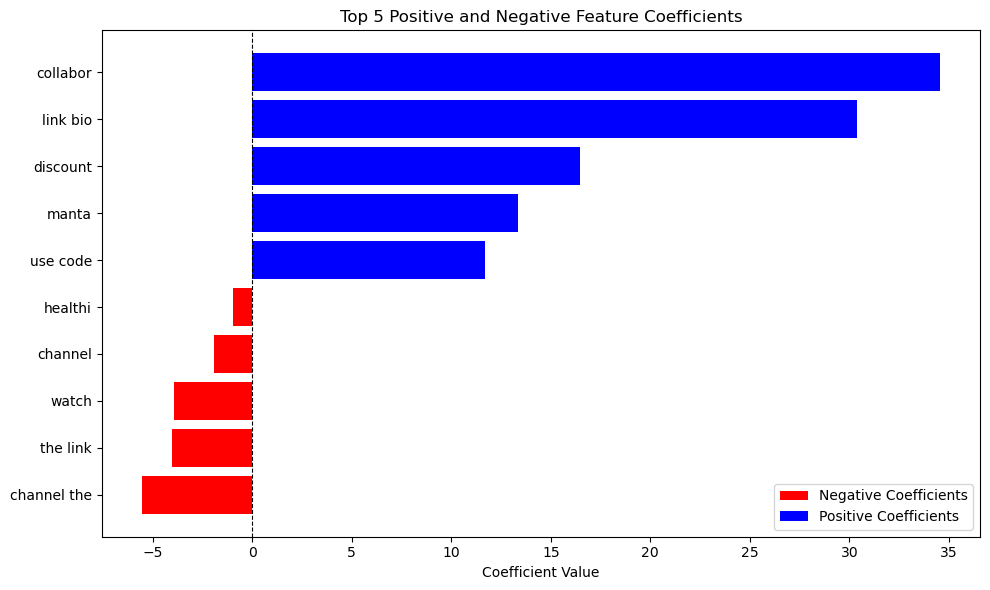

In [15]:
import matplotlib.pyplot as plt

# Re-build the coefficients dataframe using the updated model
las_coef = pd.DataFrame({
    'coef': logit_lasso.coef_[0], 
    'feature_name': [col for col in X_train.columns if col not in non_feat]
})

# Grab top and bottom features
top_feat = las_coef.sort_values(by='coef', ascending=True)[-5:]
bot_feat = las_coef.sort_values(by='coef', ascending=True)[0:5]

# Clear any hidden formatting and build the plot
plt.figure(figsize=(10, 6))

# Plot both sets of features
plt.barh(bot_feat.feature_name, bot_feat.coef, color='red', label='Negative Coefficients')
plt.barh(top_feat.feature_name, top_feat.coef, color='blue', label='Positive Coefficients')

# Add styling details
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title('Top 5 Positive and Negative Feature Coefficients')
plt.legend()
plt.tight_layout()

# Force Colab to output the chart
plt.show()

In [16]:
def tune_logit_lasso(c_val, X_tr, X_te, y_tr, y_te):
    # 1. Define the model with the specific C parameter
    model = LogisticRegression(
        penalty="l1", 
        C=c_val, 
        solver="saga", 
        max_iter=100, 
        random_state=42
    )
    
    # 2. Fit the model on the training data
    model.fit(X_tr, y_tr)
    
    # 3. Make predictions on the test data
    preds = model.predict(X_te)
    
    # 4. Return results as a DataFrame
    result_df = pd.DataFrame({
        'C_value': c_val,
        'y_true': y_te,
        'y_pred': preds
    })
    
    return result_df

In [ ]:
# List of C parameters to test (from strong regularization to weak)
c_list = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

# List to store the DataFrame output of each iteration
all_results = []

# Loop through each C value
for c in c_list:
    print(f"Training model with C = {c}...")
    df_output = tune_logit_lasso(c, X_train, X_test, y_train, y_test)
    all_results.append(df_output)

# Bind them all into one massive DataFrame
combined_predictions_df = pd.concat(all_results, ignore_index=True)

Training model with C = 0.001...
Training model with C = 0.01...
Training model with C = 0.1...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Training model with C = 1.0...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Training model with C = 10.0...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Training model with C = 100.0...


In [ ]:
from sklearn.metrics import precision_score

# Group by the hyperparameter and calculate precision
precision_scores = (
    combined_predictions_df.groupby('C_value')
    .apply(lambda one_df: precision_score(one_df['y_true'], one_df['y_pred'], zero_division=0))
    .reset_index()
)

# Rename columns for clarity
precision_scores.columns = ['C_value', 'Precision']

# Display the sorted results to see which one scores the best
print("\n--- Hyperparameter Performance Results ---")
print(precision_scores.sort_values(by='Precision', ascending=False))

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Scan the file headers to find the date column dynamically (saves RAM)
header_df = pd.read_csv("/cleanedData.csv", nrows=0)
columns = header_df.columns.tolist()

date_col = None
for col in columns:
    if any(x in col.lower() for x in ['date', 'time', 'created', 'timestamp']):
        date_col = col
        break

if date_col is None:
    print(f"Available columns: {columns}")
    raise KeyError("Could not automatically find a date/time column. Please manually change date_col to your date column name.")

print(f"Success! Detected '{date_col}' as the date/time column.")

# 2. Memory Optimization: Load ONLY the 3 columns we need
df_time = pd.read_csv("/cleanedData.csv", usecols=["post_owner.type", "text_clean", date_col])

# Filter strictly for creator accounts and drop empty rows
df_time = df_time[df_time["post_owner.type"] == "creator"].copy()
df_time = df_time.dropna(subset=[date_col, 'text_clean'])

# 3. Apply your commercial labeling function
def label_post(text):
    text_lower = str(text).lower()
    commercial_signals = [
        r'link in bio', r'swipe up', r'use code', r'promo code',
        r'discount', r'affiliate', r'sponsored', r'#ad\b', r'#spon\b',
        r'shop now', r'buy now', r'dm me', r'click the link',
        r'\$\d+', r'% off', r'free shipping', r'collab'
    ]
    for pattern in commercial_signals:
        if re.search(pattern, text_lower):
            return 1
    return 0

df_time['label'] = df_time['text_clean'].apply(label_post)

# 4. Clean up the dates and sort chronologically
df_time[date_col] = pd.to_datetime(df_time[date_col], errors='coerce')
df_time = df_time.dropna(subset=[date_col])
df_time = df_time.sort_values(by=date_col)

# Create period dimensions
df_time['year_month'] = df_time[date_col].dt.to_period('M')
df_time['year'] = df_time[date_col].dt.year

# 5. Aggregate metrics by month
monthly_data = df_time.groupby('year_month').agg(
    total_posts=('label', 'count'),
    business_posts=('label', 'sum')
).reset_index()

monthly_data['personal_posts'] = monthly_data['total_posts'] - monthly_data['business_posts']
monthly_data['pct_business'] = (monthly_data['business_posts'] / monthly_data['total_posts']) * 100
monthly_data['month_timestamp'] = monthly_data['year_month'].dt.to_timestamp()


# Vis 1
plt.figure(figsize=(12, 5))
plt.plot(monthly_data['month_timestamp'], monthly_data['pct_business'], color='#1A73E8', marker='o', linewidth=2.5, label='Business %')
plt.title('The Professionalization Shift: % of Creator Captions with Commercial Signals Over Time', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=11)
plt.ylabel('% of Content Labeled as Business', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
plt.savefig("../Output/vis1.png")


# Vis 2

plt.figure(figsize=(12, 5))
plt.stackplot(monthly_data['month_timestamp'], 
              monthly_data['personal_posts'], 
              monthly_data['business_posts'], 
              labels=['Personal Captions (0)', 'Business/Commercial Captions (1)'],
              colors=['#78909C', '#E53935'], alpha=0.85)
plt.title('Volume Shift: Absolute Share of Personal vs. Business Content over Time', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=11)
plt.ylabel('Number of Posts', fontsize=11)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig("../Output/vis2.png")

# vis 3
yearly_data = df_time.groupby('year').agg(
    pct_business=('label', lambda x: x.mean() * 100)
).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=yearly_data, x='year', y='pct_business', palette='Blues_d')
plt.title('Year-over-Year Growth of Commercial Intent in Creator Accounts', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=11)
plt.ylabel('Average % of Business Content', fontsize=11)
for index, row in yearly_data.iterrows():
    plt.text(index, row['pct_business'] + 0.5, f"{row['pct_business']:.1f}%", color='black', ha="center", fontweight='semibold')
plt.tight_layout()
plt.show()
plt.savefig("../Output/vis3.png")